In [16]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import RFECV, RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [48]:
df = pd.read_csv("./speeddating.csv")
print(df.head())

  has_null  wave     gender   age  age_o  d_age   d_d_age  \
0      b''   1.0  b'female'  21.0   27.0    6.0  b'[4-6]'   
1      b''   1.0  b'female'  21.0   22.0    1.0  b'[0-1]'   
2      b''   1.0  b'female'  21.0   22.0    1.0  b'[0-1]'   
3      b''   1.0  b'female'  21.0   23.0    2.0  b'[2-3]'   
4      b''   1.0  b'female'  21.0   24.0    3.0  b'[2-3]'   

                                       race  \
0  b'Asian/Pacific Islander/Asian-American'   
1  b'Asian/Pacific Islander/Asian-American'   
2  b'Asian/Pacific Islander/Asian-American'   
3  b'Asian/Pacific Islander/Asian-American'   
4  b'Asian/Pacific Islander/Asian-American'   

                                     race_o samerace  ...  \
0            b'European/Caucasian-American'     b'0'  ...   
1            b'European/Caucasian-American'     b'0'  ...   
2  b'Asian/Pacific Islander/Asian-American'     b'1'  ...   
3            b'European/Caucasian-American'     b'0'  ...   
4               b'Latino/Hispanic American'  

In [18]:
# Drop rows or cols with too much missing values
df = df.dropna(thresh=0.9*len(df.columns))
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.4].index.tolist()
print(f"Dropping columns with > 40% missing: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)
print(df.shape)

Dropping columns with > 40% missing: ['expected_num_interested_in_me']
(8155, 122)


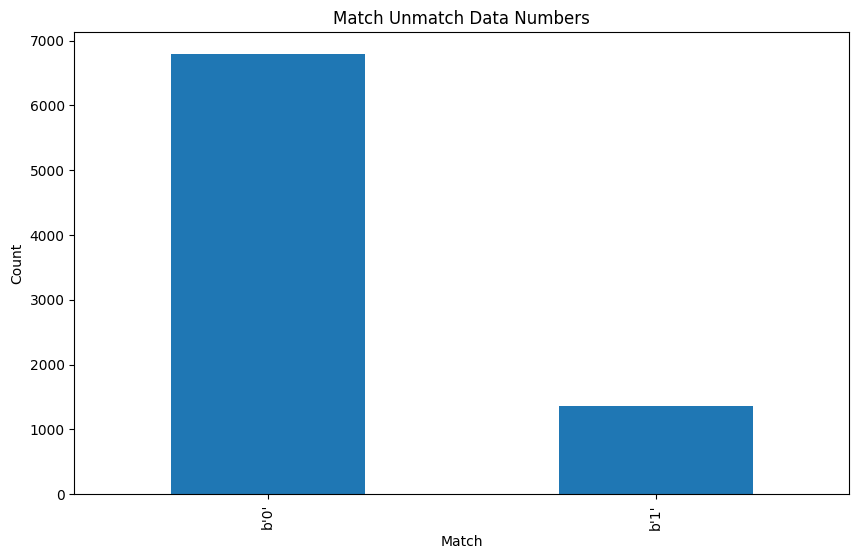

In [19]:
# Show match unmatch data numbers
# Data is unbalanced, so maybe we can try some undersampling or oversampling methods
# https://medium.com/@dakshrathi/handling-imbalanced-data-key-techniques-for-better-machine-learning-6e33b466f8b7
plt.figure(figsize=(10, 6))
df['match'].value_counts().plot(kind='bar')
plt.title('Match Unmatch Data Numbers')
plt.xlabel('Match')
plt.ylabel('Count')
plt.show()

In [49]:
# Change string columns to one hot encoding
object_cols = df.select_dtypes(include=['object']).columns
object_cols = [c for c in object_cols if c != 'match']

# Simple encoding for object columns
encoder = OrdinalEncoder()
for col in object_cols:
    if df[col].nunique() < 10:
        df[col] = encoder.fit_transform(df[[col]])
        df[col] = df[col].astype(int)
    else:
        df = df.drop(columns=[col]) # Drop high cardinality (col: field)

df['match'] = df['match'].str.replace("b'", "").str.replace("'", "")
df['match'] = pd.to_numeric(df['match'], errors='coerce')



In [50]:
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1.0,0,21.0,27.0,6.0,2,1,3,0,...,0,1,7.0,6.0,1,1,0.0,1,0,0
1,0,1.0,0,21.0,22.0,1.0,0,1,3,0,...,0,1,7.0,5.0,1,1,1.0,1,0,0
2,0,1.0,0,21.0,22.0,1.0,0,1,1,1,...,0,1,7.0,NaN,1,0,1.0,1,1,1
3,0,1.0,0,21.0,23.0,2.0,1,1,3,0,...,0,1,7.0,6.0,1,1,0.0,1,1,1
4,0,1.0,0,21.0,24.0,3.0,1,1,4,0,...,0,1,6.0,6.0,1,1,0.0,1,1,1


In [21]:
# Feature Engineering

interactions = [
    ('pref_o_attractive', 'attractive_o', 'pref_attractive'),
    ('pref_o_sincere', 'sinsere_o', 'pref_sincere'),
    ('pref_o_intellicence', 'intelligence_o', 'pref_intellicence'),
    ('pref_o_funny', 'funny_o', 'pref_funny'),
    ('pref_o_ambtition', 'ambitous_o', 'pref_ambtition'),
    ('pref_o_shared_interests', 'shared_interests_o', 'pref_shared_interests'),
    ('attractive_important', "attractive_partner", "attr_imp_x_rating"),
    ('sincere_important', "sincere_partner", "sinc_imp_x_rating"),
    ('intellicence_important', "intelligence_partner", "intel_imp_x_rating"),
    ('funny_important', "funny_partner", "fun_imp_x_rating"),
    ('ambtition_important', "ambitious_partner", "amb_imp_x_rating"),
    ('shared_interests_important', "shared_interests_partner", "shar_imp_x_rating")
]

for imp, rating, new_col in interactions:
    if imp in df.columns and rating in df.columns:
        df[new_col] = df[imp] * df[rating]


# Feature Scaling
float_cols = df.select_dtypes(include=['float']).columns
scaler = StandardScaler()
df[float_cols] = scaler.fit_transform(df[float_cols])

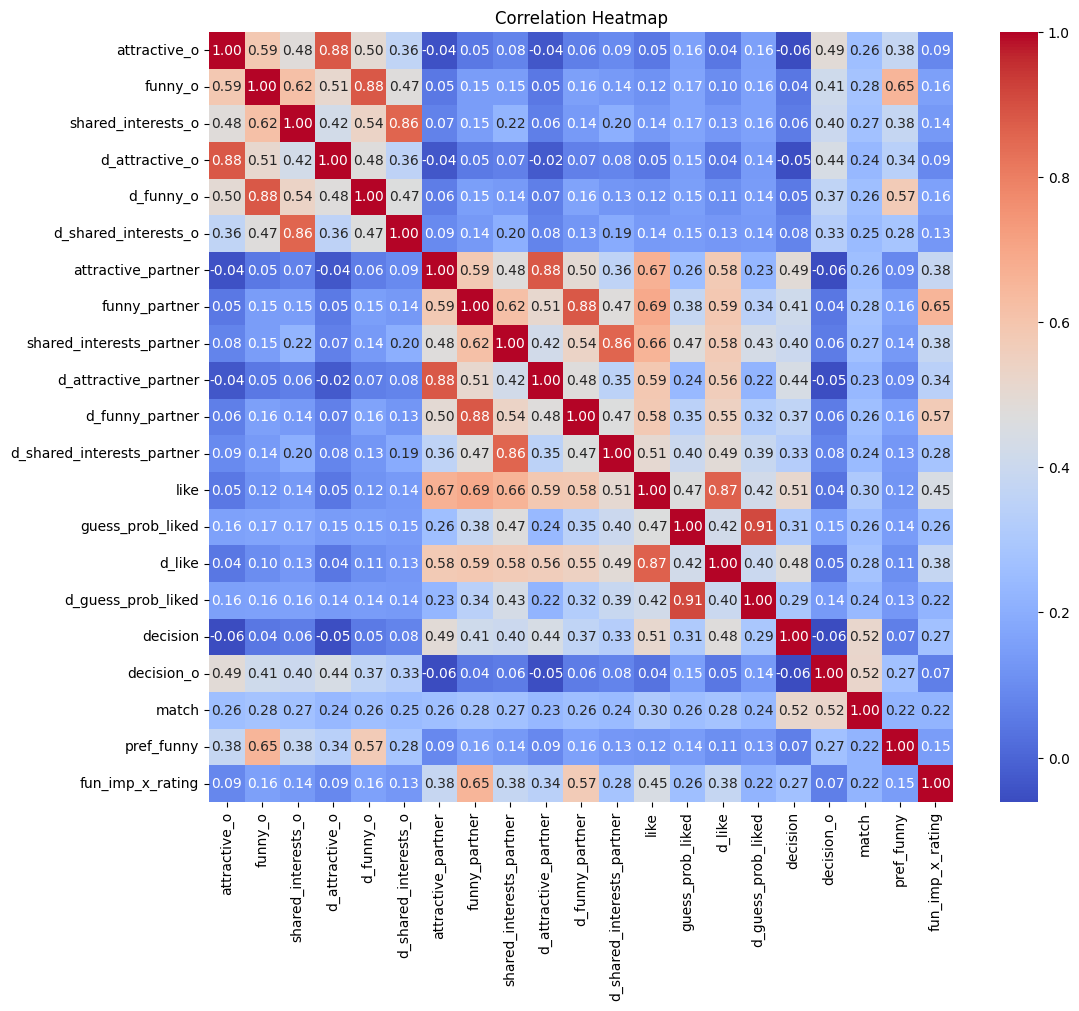

In [22]:
# Increase the figure size for better readability
plt.figure(figsize=(12, 10))
correlations = df.corr()['match']
top_features = correlations[correlations > 0.18].index

# Draw the heatmap
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
# plt.show()
plt.savefig("corr.png")

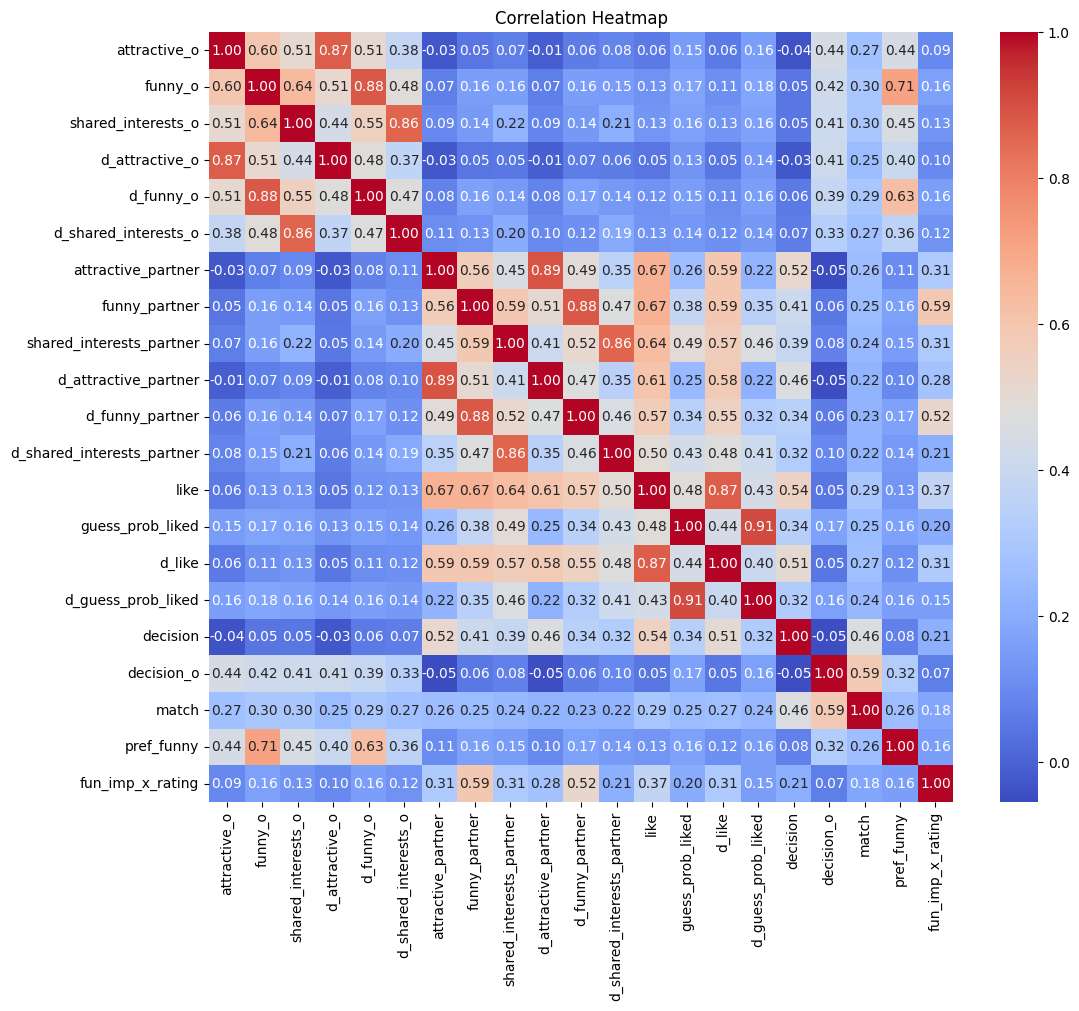

In [23]:
# Increase the figure size for better readability
plt.figure(figsize=(12, 10))
correlations = df[df["gender"] == 1].corr()['match']
top_features = correlations[correlations > 0.18].index

# Draw the heatmap
sns.heatmap(df[df["gender"] == 1][top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
# plt.show()
plt.savefig("corr_male.png")

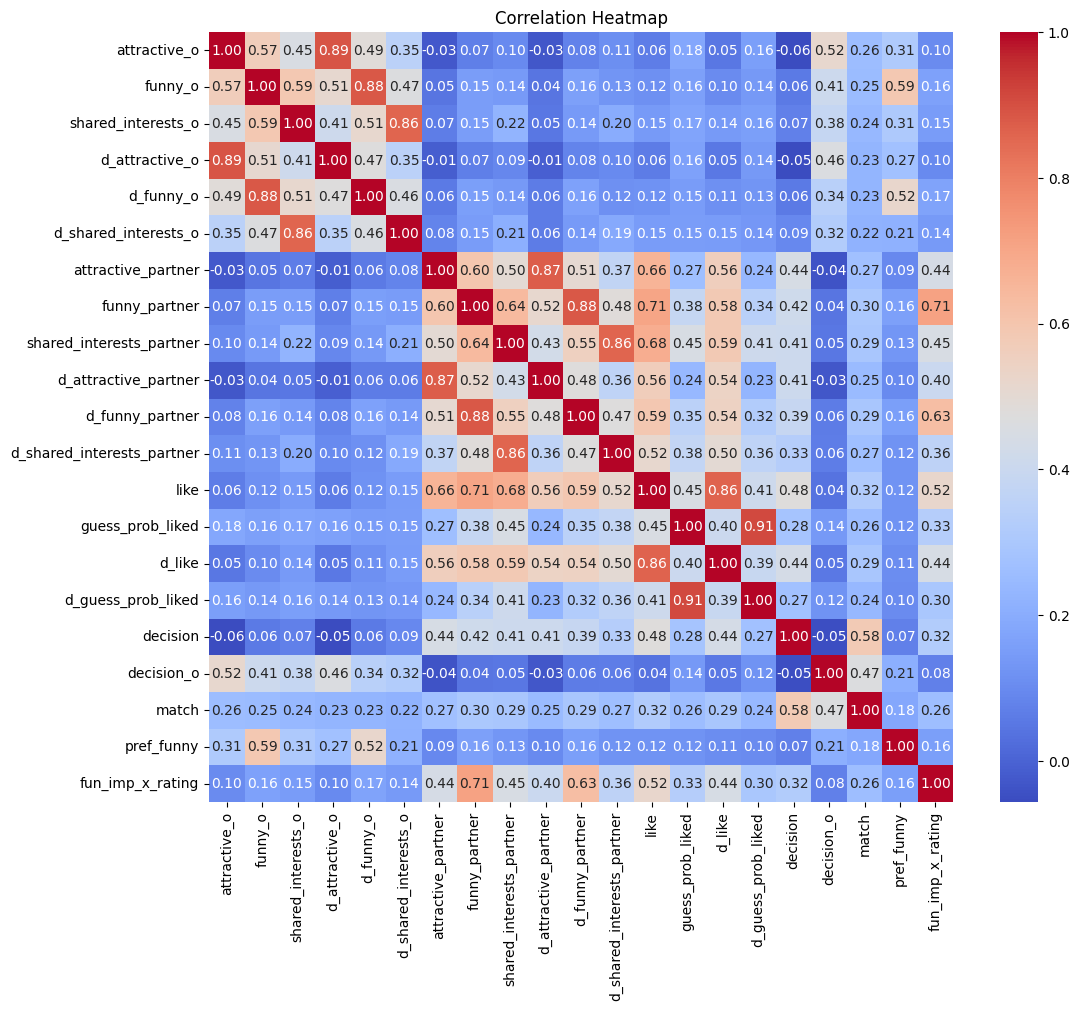

In [24]:
# Increase the figure size for better readability
plt.figure(figsize=(12, 10))
correlations = df[df["gender"] == 0].corr()['match']
top_features = correlations[correlations > 0.18].index

# Draw the heatmap
sns.heatmap(df[df["gender"] == 0][top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
# plt.show()
plt.savefig("corr_female.png")

In [25]:
df.drop(["decision", "decision"], axis=1, inplace=True)

In [26]:
# Training Data Preparation
# By decision and decision_o, we can 100% predict the match, so I drop them here.
X = df.drop(["match"], axis=1)
y = df["match"]

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [27]:
# Feature Selection

# Define the base model
model = LogisticRegression(max_iter=5000)

# Apply RFE
rfe = RFE(estimator=model, n_features_to_select=15)
rfe.fit(X_train, y_train)

# Predict and evaluate
y_pred = rfe.predict(X_test)
print("Selected features:", X.columns[rfe.support_])
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Selected features: Index(['gender', 'attractive_important', 'intellicence_important',
       'd_attractive_important', 'd_intellicence_important', 'd_intelligence',
       'attractive_partner', 'intelligence_partner', 'funny_partner',
       'ambition_partner', 'expected_num_matches', 'like', 'decision_o',
       'attr_imp_x_rating', 'intel_imp_x_rating'],
      dtype='object')
Test Accuracy: 0.9086450030656039


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1367
           1       0.73      0.69      0.71       264

    accuracy                           0.91      1631
   macro avg       0.84      0.82      0.83      1631
weighted avg       0.91      0.91      0.91      1631



In [29]:
selected_columns = X_train.columns[rfe.support_]

# Base Model
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Base Model with RFE
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train[selected_columns], y_train)
y_pred = clf.predict(X_test[selected_columns])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1367
           1       0.73      0.73      0.73       264

    accuracy                           0.91      1631
   macro avg       0.84      0.84      0.84      1631
weighted avg       0.91      0.91      0.91      1631

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1367
           1       0.73      0.69      0.71       264

    accuracy                           0.91      1631
   macro avg       0.84      0.82      0.83      1631
weighted avg       0.91      0.91      0.91      1631



In [30]:
# df.to_csv("speeddating_processed.csv")

### Thoughts

1. Data is imbalanced, so we might need to use some techniques to handle it. (SMOTE, oversampling, undersampling) Also, we might need metrics like f1 score, precision, recall, etc. to evaluate the model.
2. Decision and Decision_o are features that can 100% predict the target variable. We might need to remove them to avoid data leakage.
3. Some possible thoughts: 

    - Predicting decision and decision_o, and then using the predicted results to get the target variable. (or predict the target variable directly)
    - Slightly different between how male and female make decisions, and how their decisions affect the match.
    - Boosting Algorithms like XGBoost or Random Forest with ensemble is what I found online.

### What I did (so far)
1. Drop rows and cols with too many missing values
2. Drop decision and decision_o
3. Impute missing values with median
4. Correlation analysis, recursive feature elimination for reference
5. Categorical encoding and standardize numeric features

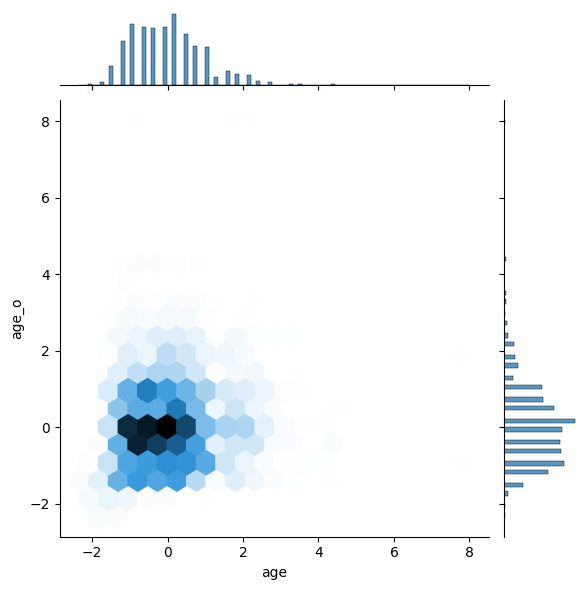

In [33]:
sns.jointplot(data=df, x='age', y='age_o', kind='hex', gridsize=20)
plt.show()

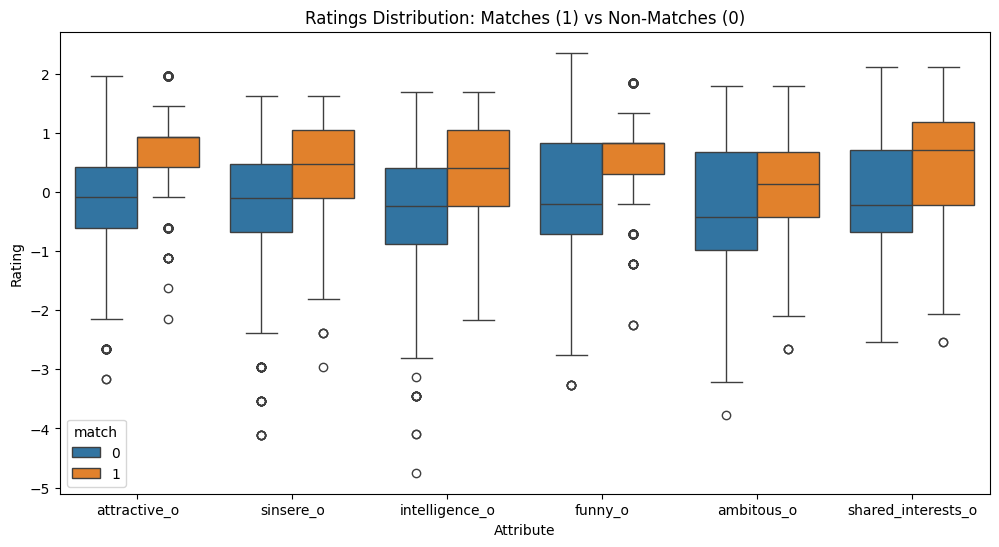

In [47]:
# Melt the data to compare multiple attributes side-by-side

cols_to_plot = ['attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o']
df_melted = df[df['gender'] == 0].melt(id_vars=['match'], value_vars=cols_to_plot, 
                    var_name='Attribute', value_name='Rating')

# Visualize the difference in ratings between Matches and Non-Matches
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Attribute', y='Rating', hue='match')
plt.title("Ratings Distribution: Matches (1) vs Non-Matches (0)")
plt.show()